In [1]:
!pip install pandas torch torchvision Pillow numpy matplotlib pathlib cairosvg

In [2]:
# Detect Device
import torch
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


In [34]:
# For Google Colab
# import shutil, os

# Run this ONCE at the start of your session
# if not os.path.exists('/content/data'):
#     shutil.copytree('drive/MyDrive/data/', '/content/data')
#     print('Data copied to local storage')

In [4]:
# Read CSV data
import csv
import pandas as pd

data = pd.read_csv('data/pokemon.csv')
print(f"Total number of samples: {len(data)}")
data.head()

Total number of samples: 1024


,id,name,primary_type,secondary_type,color,shape,sprite_file
0,1,bulbasaur,grass,poison,green,quadruped,sprites/0001.png
1,2,ivysaur,grass,poison,green,quadruped,sprites/0002.png
2,3,venusaur,grass,poison,green,quadruped,sprites/0003.png
3,4,charmander,fire,NaN,red,upright,sprites/0004.png
4,5,charmeleon,fire,NaN,red,upright,sprites/0005.png


In [5]:
# Build type, color and shape dictionaries
type_to_idx = {}
color_to_idx = {}
shape_to_idx = {}

for idx, type in enumerate(data['primary_type'].unique()):
    type_to_idx[type] = idx
for idx, color in enumerate(data['color'].unique()):
    color_to_idx[color] = idx
for idx, shape in enumerate(data['shape'].unique()):
    shape_to_idx[shape] = idx

print(type_to_idx)
print(color_to_idx)
print(shape_to_idx)


{'grass': 0, 'fire': 1, 'water': 2, 'bug': 3, 'normal': 4, 'poison': 5, 'electric': 6, 'ground': 7, 'fairy': 8, 'fighting': 9, 'psychic': 10, 'rock': 11, 'ghost': 12, 'ice': 13, 'dragon': 14, 'dark': 15, 'steel': 16, 'flying': 17}
{'green': 0, 'red': 1, 'blue': 2, 'white': 3, 'brown': 4, 'yellow': 5, 'purple': 6, 'pink': 7, 'gray': 8, 'black': 9}
{'quadruped': 0, 'upright': 1, 'armor': 2, 'squiggle': 3, 'bug-wings': 4, 'wings': 5, 'humanoid': 6, 'legs': 7, 'blob': 8, 'heads': 9, 'tentacles': 10, 'arms': 11, 'fish': 12, 'ball': 13}


In [6]:
import torchvision.transforms as transforms
from PIL import Image

class PokemonDataset(torch.utils.data.Dataset):
    def __init__(self, images, data, type_to_idx, color_to_idx, shape_to_idx):
        self.images = images
        self.data = data
        self.type_to_idx = type_to_idx
        self.color_to_idx = color_to_idx
        self.shape_to_idx = shape_to_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = f'data/{self.images[idx]}'
        img = Image.open(img_path).convert('RGBA')
        background = Image.new('RGB', img.size, (255, 255, 255))
        background.paste(img, mask=img.split()[3])  # alpha channel as mask
        image = background
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomRotation(15),
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])
        image = transform(image)

        row = self.data.iloc[idx]

        type_idx = self.type_to_idx[row['primary_type']]
        color_idx = self.color_to_idx[row['color']]
        shape_idx = self.shape_to_idx[row['shape']]

        return (image, torch.tensor([type_idx, color_idx, shape_idx], dtype=torch.long))

In [7]:
dataset = PokemonDataset(data['sprite_file'], data, type_to_idx, color_to_idx, shape_to_idx)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Number of batches: {len(dataloader)}")
print(f"Batch size: {dataloader.batch_size}")
print(f"First batch shapes: {next(iter(dataloader))[0].shape}, {next(iter(dataloader))[1].shape}")

Number of batches: 16
Batch size: 64
First batch shapes: torch.Size([64, 3, 64, 64]), torch.Size([64, 3])


In [8]:
import torch.nn as nn
class ConditionEmbedding(nn.Module):
    def __init__(self, num_types, num_colors, num_shapes, embedding_dims=[16, 8 ,8], condition_dim=32):
        super(ConditionEmbedding, self).__init__()
        self.type_embedding = nn.Embedding(num_types, embedding_dims[0])
        self.color_embedding = nn.Embedding(num_colors, embedding_dims[1])
        self.shape_embedding = nn.Embedding(num_shapes, embedding_dims[2])
        self.condition_embedding = nn.Linear(sum(embedding_dims), condition_dim)

    def forward(self, conditions):
        type_emb = self.type_embedding(conditions[:, 0])
        color_emb = self.color_embedding(conditions[:, 1])
        shape_emb = self.shape_embedding(conditions[:, 2])
        combined = torch.cat([type_emb, color_emb, shape_emb], dim=1)
        linear_emb = self.condition_embedding(combined)
        return torch.relu(linear_emb)

In [9]:
cond_emb = ConditionEmbedding(len(type_to_idx), len(color_to_idx), len(shape_to_idx)).to(device)
images, conditions = next(iter(dataloader))
out = cond_emb(conditions.to(device))
print(out.shape)

torch.Size([64, 32])


In [12]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.groupnorm1 = nn.GroupNorm(8, out_channels)
        self.activation = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.groupnorm2 = nn.GroupNorm(8, out_channels)
        self.cond_proj = nn.Linear(cond_dim, out_channels)
        self.skip_proj = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x, cond):
        residual = x
        out = self.conv1(x)
        out = self.groupnorm1(out)
        out = self.activation(out)
        cond_emb = self.cond_proj(cond).unsqueeze(2).unsqueeze(3)
        out = out + cond_emb
        out = self.conv2(out)
        out = self.groupnorm2(out)
        out = self.activation(out)
        if self.skip_proj:
            residual = self.skip_proj(residual)
        return out + residual

In [11]:
block = ResBlock(64, 128, cond_dim=32)
x = torch.randn(4, 64, 32, 32)
cond = torch.randn(4, 32)
print(block(x, cond).shape)  # expect [4, 128, 32, 32]

torch.Size([4, 128, 32, 32])


In [13]:
class UNet(nn.Module):
    def __init__(self, cond_dim=32):
        super(UNet, self).__init__()
        self.stem = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        # Encoder
        self.enc1 = ResBlock(64, 64, cond_dim)
        self.down1 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)
        self.enc2 = ResBlock(64, 128, cond_dim)
        self.down2 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)
        self.enc3 = ResBlock(128, 256, cond_dim)
        self.down3 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1)
        # Bottleneck
        self.bottleneck = ResBlock(256, 256, cond_dim)
        # Decoder
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = ResBlock(512, 256, cond_dim)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = ResBlock(384, 128, cond_dim)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = ResBlock(192, 64, cond_dim)
        #Output
        self.output = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x, cond):
        x = self.stem(x)
        s1 = self.enc1(x, cond)
        x = self.down1(s1)
        s2 = self.enc2(x, cond)
        x = self.down2(s2)
        s3 = self.enc3(x, cond)
        x = self.down3(s3)
        x = self.bottleneck(x, cond)
        x = self.up3(x)
        x = torch.cat([x, s3], dim=1)
        x = self.dec3(x, cond)
        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.dec2(x, cond)
        x = self.up1(x)
        x = torch.cat([x, s1], dim=1)
        x = self.dec1(x, cond)
        return self.output(x)

In [13]:
unet = UNet(cond_dim=32)
x = torch.randn(4, 3, 64, 64)
cond = torch.randn(4, 32)
print(unet(x, cond).shape)  # expect [4, 3, 64, 64]

torch.Size([4, 3, 64, 64])


In [14]:
class DiffusionSchedule(nn.Module):
    def __init__(self, T=1000):
        super().__init__()
        self.T = T
        t_vals = torch.arange(T+1)
        offset = 0.008
        f = torch.cos((t_vals / T + offset) / (1 + offset) * torch.pi / 2) ** 2

        self.register_buffer('alphas_bar', f[1:] / f[0])

    def add_noise(self, x0, t):
        alpha_bar = self.alphas_bar[t].reshape(x0.shape[0], 1, 1, 1)
        epsilon = torch.randn_like(x0)
        xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon
        return xt, epsilon

In [15]:
schedule = DiffusionSchedule(T=1000)
x0 = torch.randn(4, 3, 64, 64)
t = torch.randint(0, 1000, (4,))
xt, epsilon = schedule.add_noise(x0, t)
print(xt.shape)  # expect [4, 3, 64, 64]
print(epsilon.shape)  # expect [4, 3, 64, 64]

torch.Size([4, 3, 64, 64])
torch.Size([4, 3, 64, 64])


In [15]:
import torch.nn.functional as F
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

class DexGen(nn.Module):
    def __init__(self, unet, cond_emb, schedule, cond_dim):
        super(DexGen, self).__init__()
        self.unet = unet
        self.cond_emb = cond_emb
        self.schedule = schedule
        self.time_emb = nn.Embedding(schedule.T, cond_dim)

    def forward(self, x_t, t, conditions):
        attr_cond = self.cond_emb(conditions)
        time_cond = self.time_emb(t)
        cond = attr_cond + time_cond
        return self.unet(x_t, cond)

    def fit(self, num_epochs, dataloader, optimizer, device, scheduler=None, ema_model=None):
        self.to(device)
        for epoch in range(num_epochs):
            epoch_loss = 0.0
            for images, conditions in dataloader:
                images = images.to(device)
                conditions = conditions.to(device)
                t = torch.randint(0, self.schedule.T, (images.size(0),), device=device)
                x_t, epsilon = self.schedule.add_noise(images, t)
                epsilon_pred = self.forward(x_t, t, conditions)
                loss = F.mse_loss(epsilon_pred, epsilon)
                epoch_loss += loss.item()
                print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                  scheduler.step()
                if ema_model is not None:
                  ema_model.update_parameters(self)
        return epoch_loss / len(dataloader)

In [ ]:
# # Grid search for hyperparameters
import itertools

param_grid = {
    'lr': [1e-3, 1e-4],
    'cond_dim': [32, 64, 128],
    'batch_size': [32, 64],
    'num_epochs': [50, 100, 200],
}

results = []
min_loss = float('inf')
for lr, cond_dim, batch_size, num_epochs in itertools.product(*param_grid.values()):
    unet = UNet(cond_dim=cond_dim)
    cond_emb = ConditionEmbedding(len(type_to_idx), len(color_to_idx), len(shape_to_idx), condition_dim=cond_dim)
    schedule = DiffusionSchedule(T=1000)
    model = DexGen(unet, cond_emb, schedule, cond_dim=cond_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    avg_loss = model.fit(num_epochs=num_epochs, dataloader=dataloader, optimizer=optimizer, device=device)   # short run for comparison
    # record final loss somehow
    if avg_loss < min_loss:
        min_loss = avg_loss
        best_params = {'lr': lr, 'cond_dim': cond_dim, 'batch_size': batch_size, 'num_epochs': num_epochs}

print(best_params, min_loss)

In [33]:
NUM_EPOCHS = 500
unet = UNet(cond_dim=128)
cond_emb = ConditionEmbedding(len(type_to_idx), len(color_to_idx), len(shape_to_idx), condition_dim=128)
schedule = DiffusionSchedule(T=1000)
model = DexGen(unet, cond_emb, schedule, cond_dim=128)
ema_model = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(0.999))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
model.fit(num_epochs=NUM_EPOCHS, dataloader=dataloader, optimizer=optimizer, device=device, scheduler=scheduler, ema_model=ema_model)

Streaming output truncated to the last 5000 lines.
Epoch 188, Loss: 0.0471
Epoch 188, Loss: 0.0368
Epoch 188, Loss: 0.0536
Epoch 188, Loss: 0.0438
Epoch 188, Loss: 0.0606
Epoch 188, Loss: 0.0488
Epoch 188, Loss: 0.0521
Epoch 188, Loss: 0.0503
Epoch 189, Loss: 0.0492
Epoch 189, Loss: 0.0459
Epoch 189, Loss: 0.0524
Epoch 189, Loss: 0.0530
Epoch 189, Loss: 0.0459
Epoch 189, Loss: 0.0581
Epoch 189, Loss: 0.0489
Epoch 189, Loss: 0.0316
Epoch 189, Loss: 0.0589
Epoch 189, Loss: 0.0438
Epoch 189, Loss: 0.0359
Epoch 189, Loss: 0.0361
Epoch 189, Loss: 0.0451
Epoch 189, Loss: 0.0383
Epoch 189, Loss: 0.0499
Epoch 189, Loss: 0.0483
Epoch 190, Loss: 0.0524
Epoch 190, Loss: 0.0321
Epoch 190, Loss: 0.0350
Epoch 190, Loss: 0.0476
Epoch 190, Loss: 0.0425
Epoch 190, Loss: 0.0640
Epoch 190, Loss: 0.0514
Epoch 190, Loss: 0.0409
Epoch 190, Loss: 0.0577
Epoch 190, Loss: 0.0467
Epoch 190, Loss: 0.0497
Epoch 190, Loss: 0.0385
Epoch 190, Loss: 0.0586
Epoch 190, Loss: 0.0489
Epoch 190, Loss: 0.0451
Epoch 190, Lo

0.03879437199793756

In [18]:
checkpoint = torch.load('dexgen.pt', map_location=device)

type_to_idx = checkpoint['type_to_idx']
color_to_idx = checkpoint['color_to_idx']
shape_to_idx = checkpoint['shape_to_idx']
cond_dim = checkpoint['cond_dim']

# Restore model state
unet = UNet(cond_dim=cond_dim)
cond_emb = ConditionEmbedding(len(type_to_idx), len(color_to_idx), len(shape_to_idx), condition_dim=cond_dim)
schedule = DiffusionSchedule(T=1000)
model = DexGen(unet, cond_emb, schedule, cond_dim=cond_dim)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device).eval()
print("Model loaded and ready for inference")

ema_model = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(0.999))
ema_model.load_state_dict(checkpoint['ema_model_state_dict'])
ema_model.to(device).eval()
print("EMA model loaded and ready for inference")


Model loaded and ready for inference
EMA model loaded and ready for inference


In [19]:
def ddim_sample(model, schedule, conditions, num_steps, device):
    num_steps = [schedule.T-1 - i * (schedule.T // num_steps) for i in range(num_steps)]
    x = torch.randn(conditions.size(0), 3, 64, 64).to(device)
    for t, t_prev in zip(num_steps, num_steps[1:] + [0]):
        t_batch = torch.full((conditions.size(0),), t, device=device, dtype=torch.long)
        epsilon_pred = model(x, t_batch, conditions)
        alpha_bar = schedule.alphas_bar[t]
        alpha_bar_prev = schedule.alphas_bar[t_prev]
        x0_pred = (x - torch.sqrt(1 - alpha_bar) * epsilon_pred) / torch.sqrt(alpha_bar)
        x0_pred = torch.clamp(x0_pred, -1.0, 1.0)
        # recalculate the exact noise vector pointing from our clamped x0 back to x
        epsilon_rederived = (x - torch.sqrt(alpha_bar) * x0_pred) / torch.sqrt(1 - alpha_bar)
        x_t_prev = torch.sqrt(alpha_bar_prev) * x0_pred + torch.sqrt(1 - alpha_bar_prev) * epsilon_rederived
        x = x_t_prev
    return x

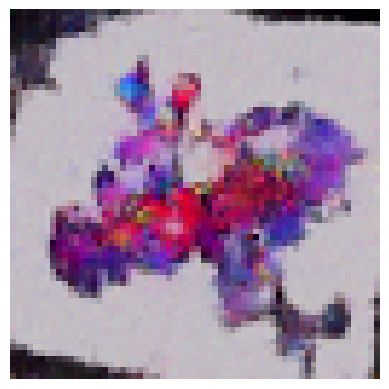

In [ ]:
import matplotlib.pyplot as plt

conditions = torch.tensor([[type_to_idx['water'], color_to_idx['blue'], shape_to_idx['quadruped']]])
ema_model.to(device)
ema_model.eval()
with torch.no_grad():
    generated = ddim_sample(ema_model, schedule, conditions.to(device), num_steps=200, device=device)
    generated = generated.cpu().squeeze().permute(1, 2, 0).numpy()
    generated = (generated + 1) / 2  # Denormalize to [0, 1]
    generated = generated.clip(0, 1)
    plt.imshow(generated, interpolation='nearest')
    plt.axis('off')
    plt.show()


In [76]:
torch.save({
    'model_state_dict': model.state_dict(),
    'ema_model_state_dict': ema_model.state_dict(),
}, 'dexgen_final.pt')